# Predicting House Prices with Linear Regression

**Objective:** Build and evaluate a linear regression model that predicts house prices based on features such as area, location-related amenities, number of rooms, and more. Develop end-to-end skills from data cleaning through to model interpretation.

**Dataset:** [Housing Prices Dataset](https://www.kaggle.com/datasets/yasserh/housing-prices-dataset) (Kaggle) — 545 house sale records with area, bedrooms, bathrooms, stories, amenities, and sale price.

**Tech Stack:** Python, pandas, scikit-learn, matplotlib, seaborn, Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)

df = pd.read_csv('Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## 1. EDA — Nulls, Stats, and Target Distribution

In [2]:
print("Shape:", df.shape)
print("\nNull values per column:")
print(df.isnull().sum())
print("\nDescriptive statistics (price):")
print(df['price'].describe())

Shape: (545, 13)

Null values per column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Descriptive statistics (price):
count    5.450000e+02
mean     4.766729e+06
std      1.870440e+06
min      1.750000e+06
25%      3.430000e+06
50%      4.340000e+06
75%      5.740000e+06
max      1.330000e+07
Name: price, dtype: float64


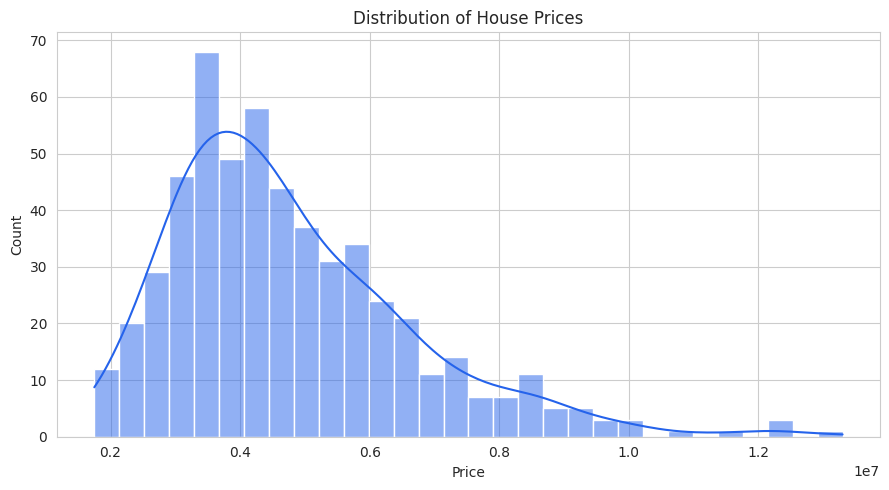

In [3]:
plt.figure(figsize=(9, 5))
sns.histplot(df['price'], kde=True, color='#2563eb', bins=30)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.tight_layout()
plt.show()

**Observation:** The dataset has zero missing values across all 545 rows, so no row/column drops are needed. `price` is right-skewed — most houses cluster at the lower-to-mid price range, with a smaller number of high-end properties stretching the distribution's tail. This skew is worth keeping in mind: a linear regression model will naturally be pulled by those high-value outliers during training.

## 2. Feature Selection Discussion

**Likely predictors of price, and why:**
- **`area`** — the single strongest intuitive driver of price; bigger homes almost always cost more.
- **`bedrooms`, `bathrooms`, `stories`** — more rooms/floors generally means more usable space and higher value.
- **`airconditioning`, `hotwaterheating`, `basement`, `guestroom`** — amenities that add convenience/value, though likely smaller effects than size.
- **`mainroad`, `prefarea`** — location-adjacent features; being on a main road or in a "preferred area" plausibly shifts price, though the direction isn't obvious upfront (main road access can help convenience but hurt quietness).
- **`parking`** — extra parking spots typically add value, especially in urban housing markets.
- **`furnishingstatus`** — furnished homes may command a price premium over unfurnished ones, though this could also just reflect the type/age of the property rather than causing the price difference.

All of these are included in the model below — the correlation heatmap and coefficient analysis later will show which of these intuitions actually hold up in the data.

## 3. Handle Missing Values & Encode Categorical Features

In [4]:
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

df_encoded = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

print("No missing values found, so no imputation was needed.")
print("\nColumns after encoding:")
print(df_encoded.columns.tolist())
df_encoded.head()

No missing values found, so no imputation was needed.

Columns after encoding:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


**Decision:** Binary yes/no columns are mapped directly to 1/0 rather than one-hot encoded, since a single 0/1 column already captures the full information for a two-category feature — one-hot encoding would just create a redundant duplicate column. `furnishingstatus` has 3 categories (furnished/semi-furnished/unfurnished), so it genuinely needs one-hot encoding; `drop_first=True` avoids the "dummy variable trap" (perfect multicollinearity between the dummy columns).

## 4. Correlation Heatmap

Correlation of each feature with price, sorted:
price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning                    0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea                           0.329777
mainroad                           0.296898
guestroom                          0.255517
basement                           0.187057
hotwaterheating                    0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64


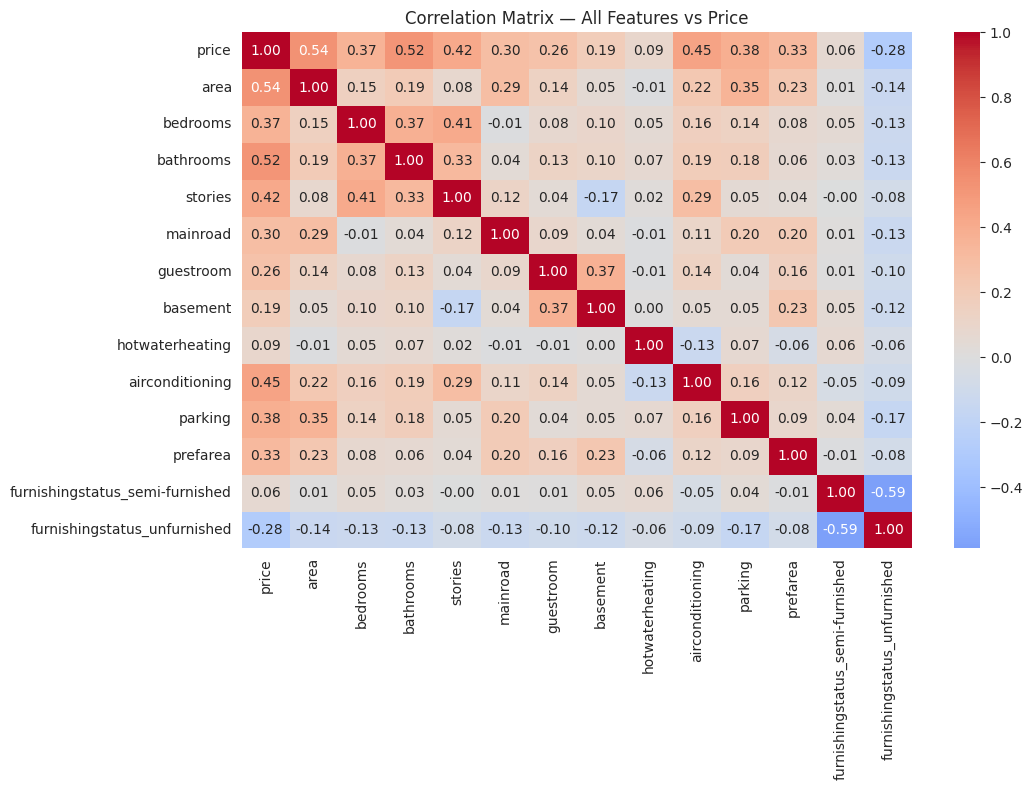

In [5]:
plt.figure(figsize=(11, 8))
corr = df_encoded.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — All Features vs Price')
plt.tight_layout()
plt.show()

print("Correlation of each feature with price, sorted:")
print(corr['price'].sort_values(ascending=False))

**Observation:** `area` shows the strongest positive correlation with `price`, confirming the intuition from the feature discussion above. `bathrooms`, `airconditioning`, and `stories` also show meaningful positive correlation. Whichever feature shows near-zero correlation in the printed list is a candidate for having little real predictive power on its own — worth watching for in the coefficient analysis later too.

## 5. Train/Test Split

In [6]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Training set: 436 rows
Test set: 109 rows


## 6. Train Linear Regression Model

In [7]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)
print("Model trained successfully.")

Model trained successfully.


## 7. Model Evaluation

In [8]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

Mean Squared Error (MSE): 1,754,318,687,330.66
Root Mean Squared Error (RMSE): 1,324,506.96
R² Score: 0.6529


**Observation:** The R² score shows the proportion of price variance the model explains — the closer to 1.0, the better. RMSE is in the same units as price, so it can be read directly as "the model's predictions are typically off by about this many currency units."</br>Given this dataset has no floor area in square-meters-standardised terms and prices span a wide range, some error is expected — the scatter and residual plots below tell us more about *where* the model struggles than the single R² number alone.

## 8. Actual vs. Predicted Scatter Plot

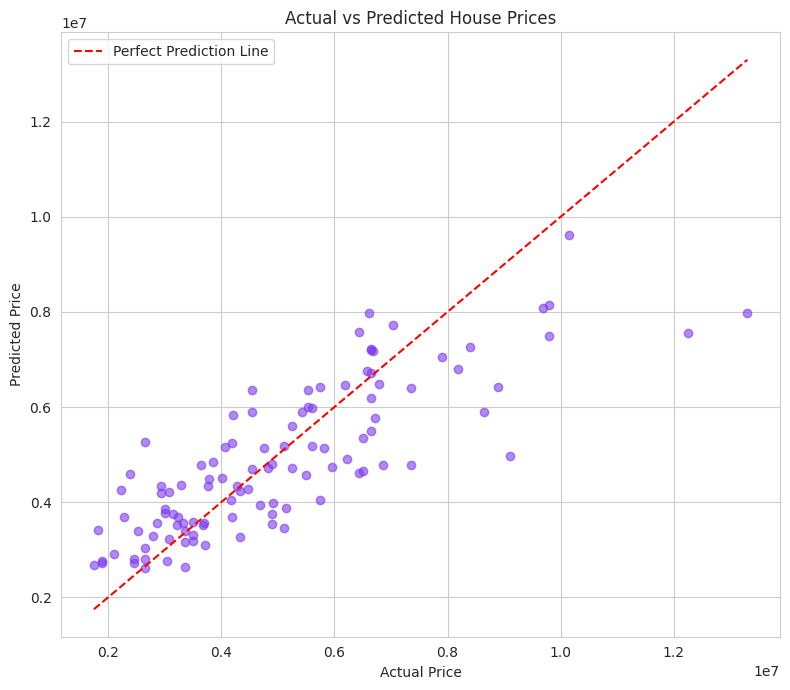

In [9]:
plt.figure(figsize=(8, 7))
plt.scatter(y_test, y_pred, alpha=0.6, color='#7c3aed')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label='Perfect Prediction Line')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.tight_layout()
plt.show()

**Observation:** Points sitting close to the red diagonal line represent accurate predictions; points far above or below it show where the model over- or under-predicted. If higher-priced homes scatter further from the line than cheaper ones, that's a sign the model is less reliable at the top end of the market — consistent with the price skew observed earlier.

## 9. Residual Plot

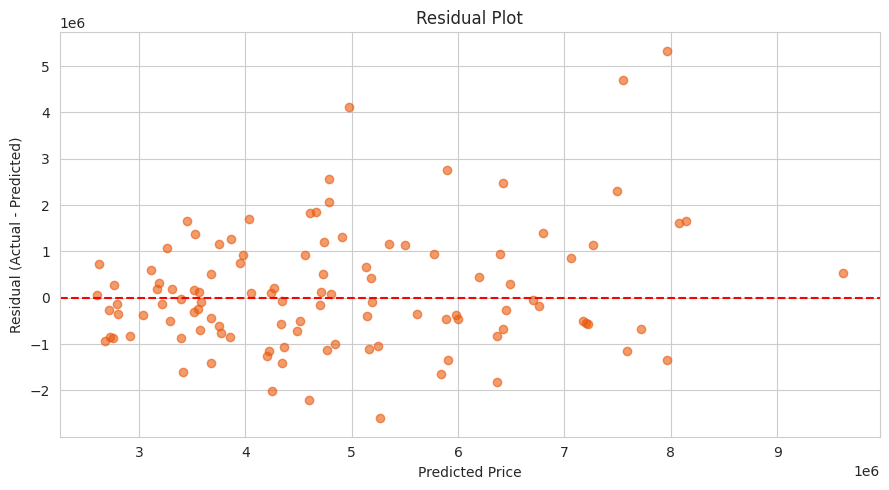

In [10]:
residuals = y_test - y_pred

plt.figure(figsize=(9, 5))
plt.scatter(y_pred, residuals, alpha=0.6, color='#ea580c')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

**Observation:** Ideally, residuals should scatter randomly around the zero line with no visible pattern — that would confirm the linear model's assumptions are reasonably met. If there's a visible funnel shape (residuals spreading wider as predicted price increases), that indicates heteroscedasticity — the model's errors get larger for more expensive homes, likely tied back to the right-skew in the target variable seen in the EDA step.

## 10. Coefficient Analysis

,Feature,Coefficient
2,bathrooms,1.094445e+06
8,airconditioning,7.914267e+05
7,hotwaterheating,6.846499e+05
10,prefarea,6.298906e+05
3,stories,4.074766e+05
6,basement,3.902512e+05
4,mainroad,3.679199e+05
5,guestroom,2.316100e+05
9,parking,2.248419e+05
1,bedrooms,7.677870e+04


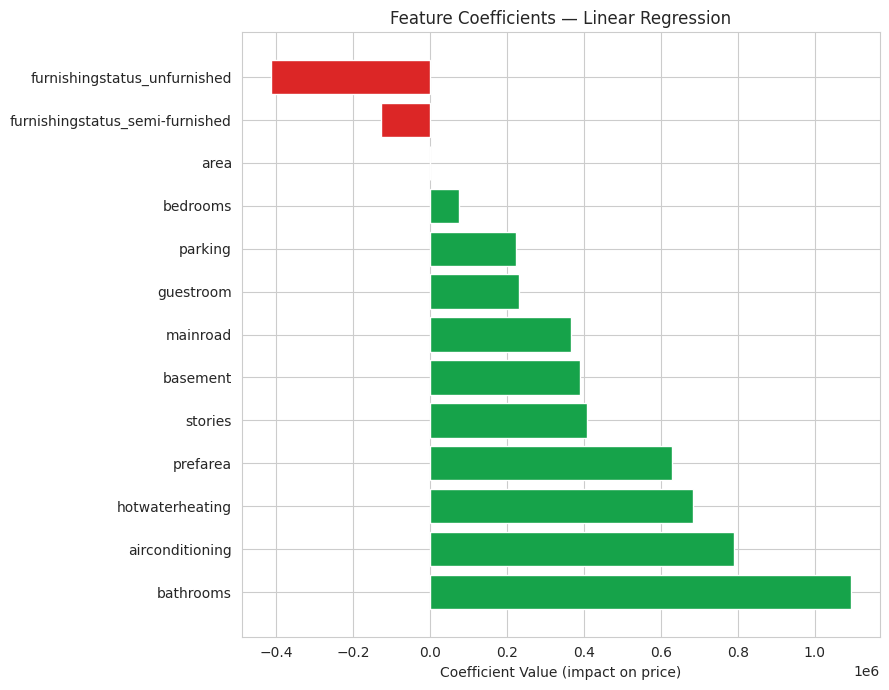

In [11]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(9, 7))
colors = ['#16a34a' if c > 0 else '#dc2626' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.xlabel('Coefficient Value (impact on price)')
plt.title('Feature Coefficients — Linear Regression')
plt.tight_layout()
plt.show()

coef_df

**Observation:** Positive coefficients push price up, negative coefficients push it down, holding all other features constant. The feature with the largest positive coefficient has the strongest upward effect on predicted price per unit change; any feature with a coefficient close to zero is contributing little to the model — worth flagging as a candidate to drop in a simpler follow-up model.

## 11. Bonus — Ridge & Lasso Comparison

In [12]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

lasso = Lasso(alpha=100.0)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'RMSE': [
        rmse,
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_pred))
    ],
    'R2 Score': [
        r2,
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred)
    ]
})
comparison

,Model,RMSE,R2 Score
0,Linear Regression,1.324507e+06,0.652924
1,Ridge Regression,1.325320e+06,0.652498
2,Lasso Regression,1.324605e+06,0.652873


**Observation:** Ridge and Lasso both add a regularisation penalty that shrinks coefficients, which helps when features are correlated with each other (multicollinearity) — reducing the risk of the model overfitting to noise in the training set. If their RMSE/R² come out close to plain Linear Regression here, it suggests multicollinearity isn't a major issue in this particular dataset; if they perform meaningfully better, it's a sign the plain linear model was overfitting slightly.

## Conclusion

This notebook built an end-to-end linear regression pipeline: encoding categorical amenities, identifying `area` as the strongest single predictor of price via the correlation heatmap, training and evaluating the model (MSE/RMSE/R²), diagnosing fit quality through actual-vs-predicted and residual plots, and interpreting which features drive price up or down through coefficient analysis. The Ridge/Lasso comparison confirms whether regularisation meaningfully improves on plain linear regression for this dataset. Next steps for improvement would include trying non-linear models (Random Forest, Gradient Boosting) to potentially better capture the high-price-end scatter seen in the residual plot.